In [1]:
from typing import TypedDict, Literal

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    total_currency: Literal['EUR', 'INR']
    total: float

In [3]:
def calculate_total(state: PortfolioState) -> PortfolioState: 
    state['total_usd'] = state['amount_usd']* 1.08
    return state

def calculate_total_inr(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 82.0
    return state

def calculate_total_eur(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 8.0
    return state

def conversion_condition(state: PortfolioState) -> str:
    return state['total_currency']    

In [4]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calculate_total", calculate_total)
builder.add_node("calculate_total_inr", calculate_total_inr)
builder.add_node("calculate_total_eur", calculate_total_eur)

builder.add_edge(START, "calculate_total")
builder.add_conditional_edges("calculate_total", conversion_condition, 
{"INR": "calculate_total_inr", "EUR": "calculate_total_eur"})
builder.add_edge(["calculate_total_inr","calculate_total_eur"], END)
graph = builder.compile()

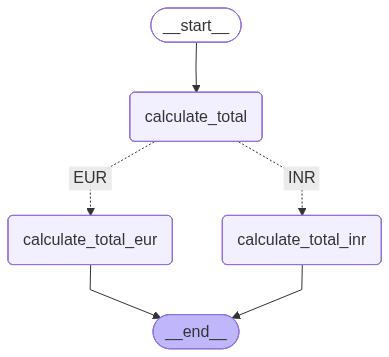

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
graph.invoke({"amount_usd": 100.0, "total_currency": "INR"})

{'amount_usd': 100.0,
 'total_usd': 108.0,
 'total_currency': 'INR',
 'total': 8856.0}